         Country/Region  Confirmed  Deaths  Recovered  Active  New cases  \
0           Afghanistan      36263    1269      25198    9796        106   
1               Albania       4880     144       2745    1991        117   
2               Algeria      27973    1163      18837    7973        616   
3               Andorra        907      52        803      52         10   
4                Angola        950      41        242     667         18   
..                  ...        ...     ...        ...     ...        ...   
182  West Bank and Gaza      10621      78       3752    6791        152   
183      Western Sahara         10       1          8       1          0   
184               Yemen       1691     483        833     375         10   
185              Zambia       4552     140       2815    1597         71   
186            Zimbabwe       2704      36        542    2126        192   

     New deaths  New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
0         

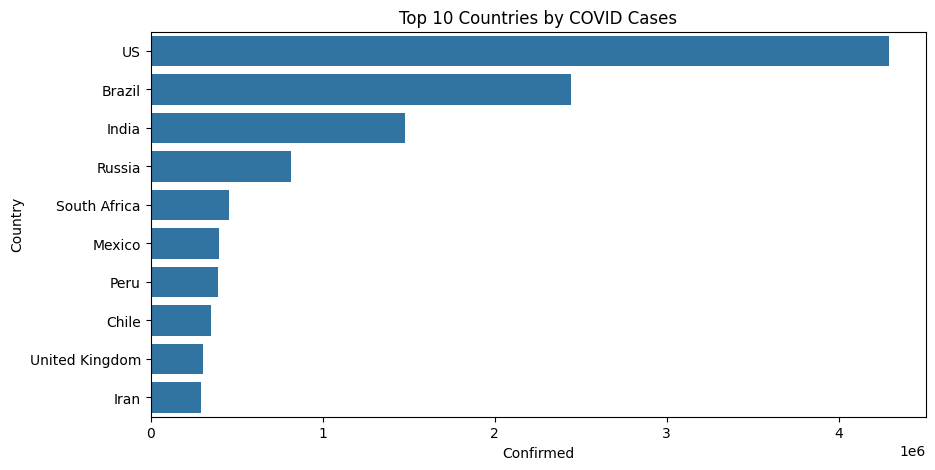

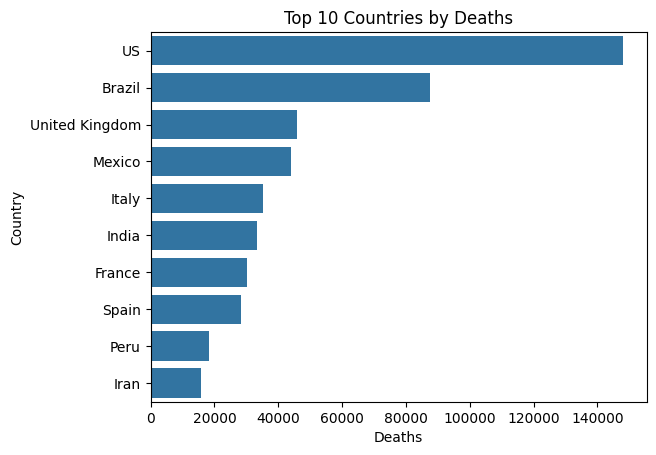

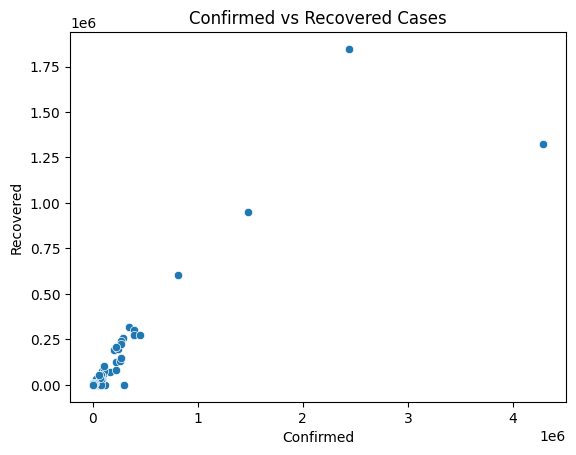

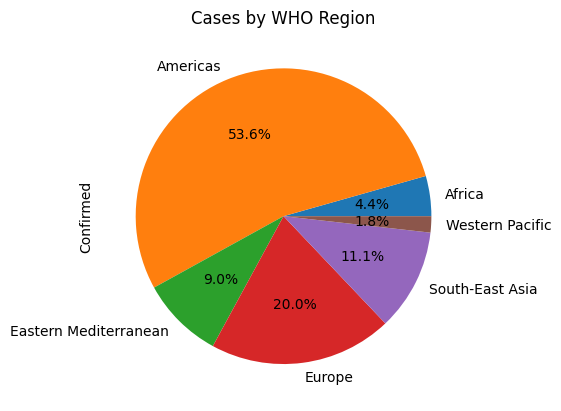

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df =pd.read_csv("/content/country_wise_latest.csv")
print(df)
# df.head(10)
# df.info()
# df.describe()
# print(df.isnull().sum())
# print(df.duplicated())
# df=df.fillna(0)
df.rename(columns={
    'Country/Region':'Country'
}, inplace=True)
df['Death Rate'] = df['Deaths'] / df['Confirmed']
top_cases = df.sort_values(by='Confirmed', ascending=False).head(10)
top_cases
plt.figure(figsize=(10,5))
sns.barplot(x='Confirmed', y='Country', data=top_cases)
plt.title("Top 10 Countries by COVID Cases")
plt.show()


top_deaths = df.sort_values(by='Deaths', ascending=False).head(10)

sns.barplot(x='Deaths', y='Country', data=top_deaths)
plt.title("Top 10 Countries by Deaths")
plt.show()

sns.scatterplot(x='Confirmed', y='Recovered', data=df)
plt.title("Confirmed vs Recovered Cases")
plt.show()
region_cases = df.groupby('WHO Region')['Confirmed'].sum()

region_cases.plot(kind='pie', autopct='%1.1f%%')
plt.title("Cases by WHO Region")
plt.show()

df.to_csv("cleaned_country_covid_data.csv", index=False)